In [1]:
import pandas as pd 
import numpy as np
import ast 
import torch as torch
import json 
import matplotlib.pyplot as plt

/home/lcmj2803/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/lcmj2803/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:

d = pd.read_csv("iq_dataset_demo.csv")

In [3]:
df = pd.read_csv("iq_dataset_demo.csv")          # lee el CSV
y_mod   = df["mod"].to_numpy(dtype=np.int64)     # etiquetas
y_order = df["order"].to_numpy(dtype=np.int64)

# convertir la cadena de lista a array y reconstruir (N, T, 2)
iq_flat = df["iq_vector"].apply(ast.literal_eval)           # lista -> objeto Python
X = np.array(iq_flat.tolist(), dtype=np.float32)            # (N, 2*T)
N, twoT = X.shape
X = X.reshape(N, twoT//2, 2)                                # -> (N, T, 2)


In [11]:
i = 2
I = X[i,:,0]
Q = X[i,:,1] 

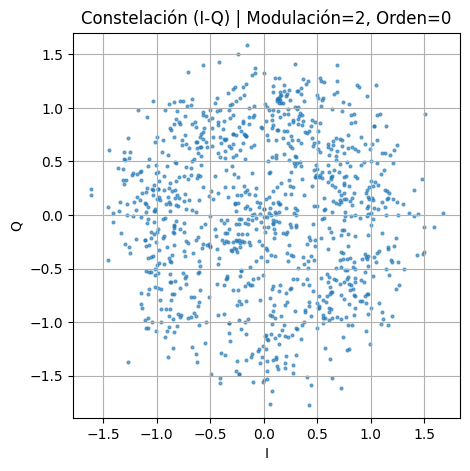

In [12]:
plt.figure(figsize=(5,5))
plt.scatter(I, Q, s=4, alpha=0.6)
plt.title(f"Constelación (I-Q) | Modulación={y_mod[i]}, Orden={y_order[i]}")
plt.xlabel("I")
plt.ylabel("Q")
plt.grid(True)
plt.axis("equal")
plt.show()
